# Laboratorio 6

## Proyecciones, comunidades y conclusiones

In [1]:
from pathlib import Path
import sys
RAIZ = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))
from scripts.analisis_final import tabla, figura

## 5. Proyecciones

La proyección autor-autor conecta autores que comentaron el mismo video y pesa cada relación por el número de videos compartidos. La proyección video-video conecta contenidos con autores en común y el peso cuenta autores únicos. Se usan vecinos distintos de la red bipartita, por lo que comentar varias veces no multiplica estos pesos. Se conservan todos los nodos, incluso los aislados. La primera representa coincidencia de participación y la segunda cruce de audiencias; ninguna representa amistad ni aprobación.

In [2]:
tabla("aristas_autores", 10)

,origen,destino,peso
0,autor:UC-HeUTT6_g-VoiWds2a4H-w,autor:UCtsxPYw8VUsH_FfnKg-0lmw,1
1,autor:UC-HeUTT6_g-VoiWds2a4H-w,autor:UCoGdCoJg2Lh0OX_jv6cG16g,1
2,autor:UC-HeUTT6_g-VoiWds2a4H-w,autor:UCaT4saRcyqCLE657Rq2hhZQ,1
3,autor:UC-HeUTT6_g-VoiWds2a4H-w,autor:UCEHXl4VvvVpq-_4xC5tsbhg,1
4,autor:UC-HeUTT6_g-VoiWds2a4H-w,autor:UC14qlobYKqD-DO0j6b75lcA,1
5,autor:UC-HeUTT6_g-VoiWds2a4H-w,autor:UC3YpzAr7pcdKC7BVFEpYzog,1
6,autor:UC-HeUTT6_g-VoiWds2a4H-w,autor:UChyps3dqY-VY1_wLeq-2lhw,1
7,autor:UC-HeUTT6_g-VoiWds2a4H-w,autor:UCvDwJBBY1mHK70aTEYl6rsA,1
8,autor:UC-HeUTT6_g-VoiWds2a4H-w,autor:UCWaRixDdpgllTBf4V0jPnKQ,1
9,autor:UC-HeUTT6_g-VoiWds2a4H-w,autor:UCiOZX__1gahg1ypIj0_XG_w,1


In [3]:
tabla("aristas_videos", 20)

,origen,destino,peso
0,video:06mFNPU0aB8,video:6W4u8sGEnGM,1
1,video:6W4u8sGEnGM,video:PjmxCj-a9Hg,1
2,video:PjmxCj-a9Hg,video:n8iP75gIpmw,1
3,video:WIUZtitfLRw,video:ndAZjHqzzT8,1
4,video:WIUZtitfLRw,video:yLZS3JiEBg8,1
5,video:b_Hkrkl3adA,video:n8iP75gIpmw,1
6,video:is3Mk5oC19g,video:j43HgwYFKfk,1
7,video:j43HgwYFKfk,video:n8iP75gIpmw,2
8,video:j43HgwYFKfk,video:ndAZjHqzzT8,1
9,video:n8iP75gIpmw,video:ndAZjHqzzT8,1


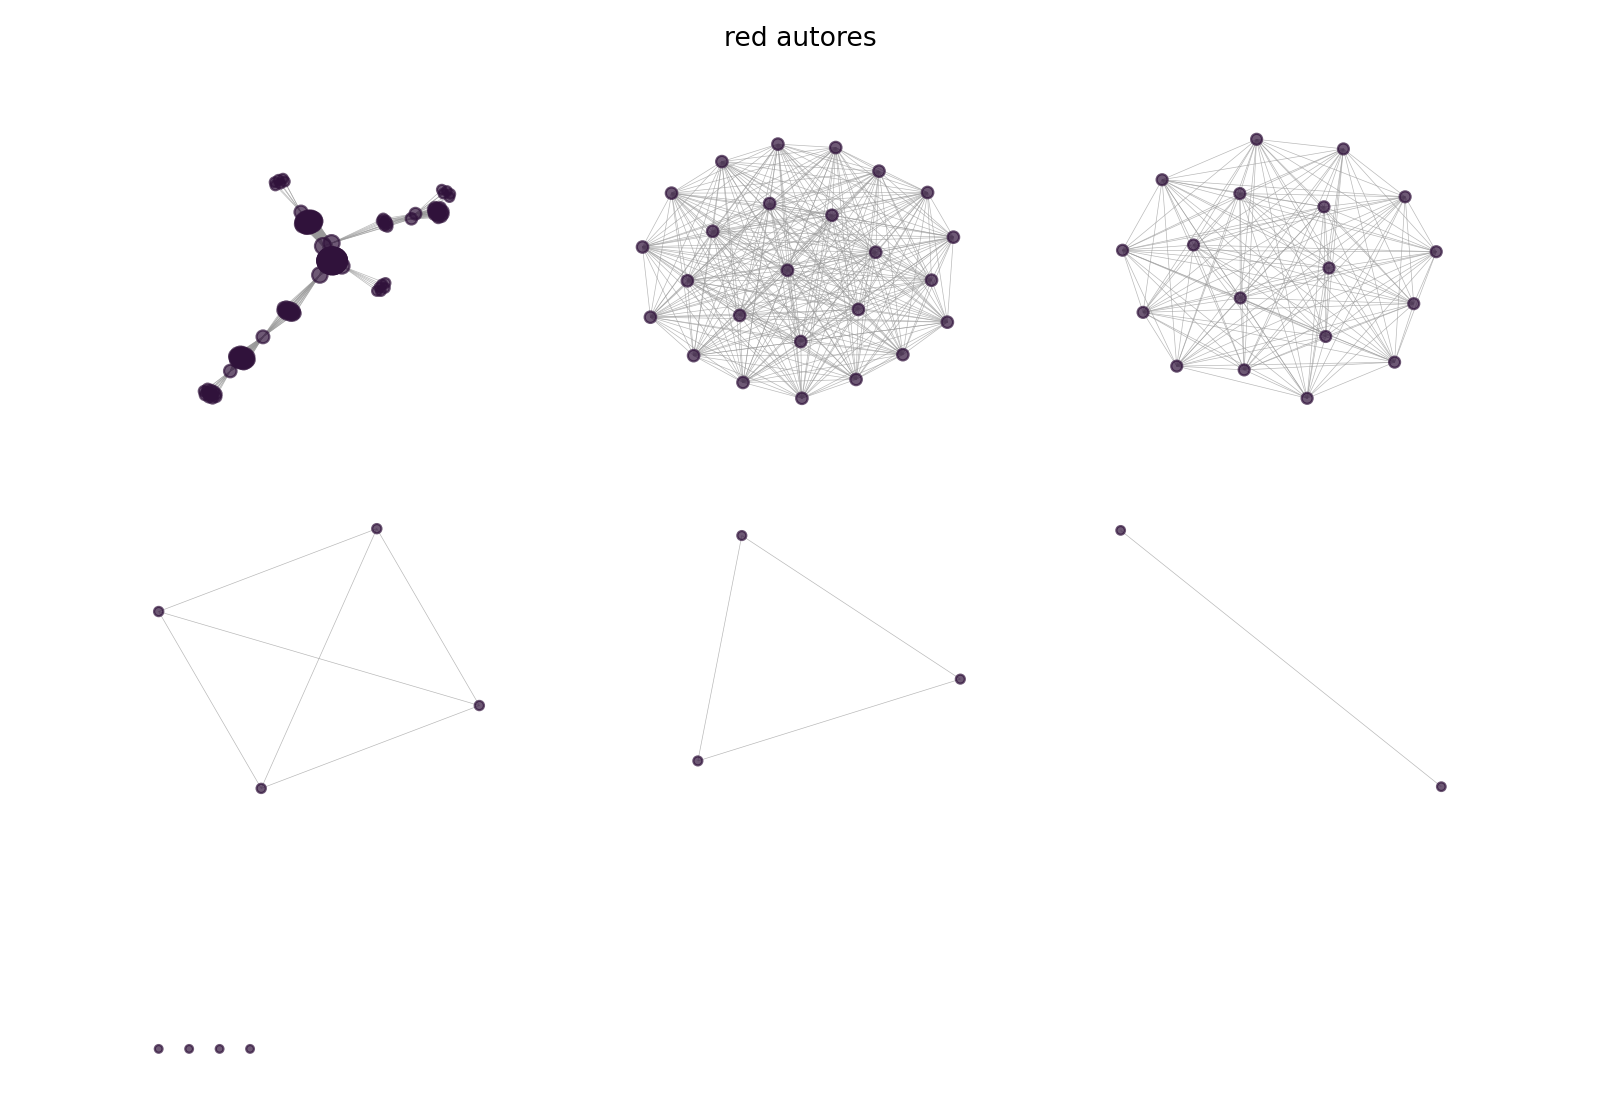

In [4]:
figura("red_autores")

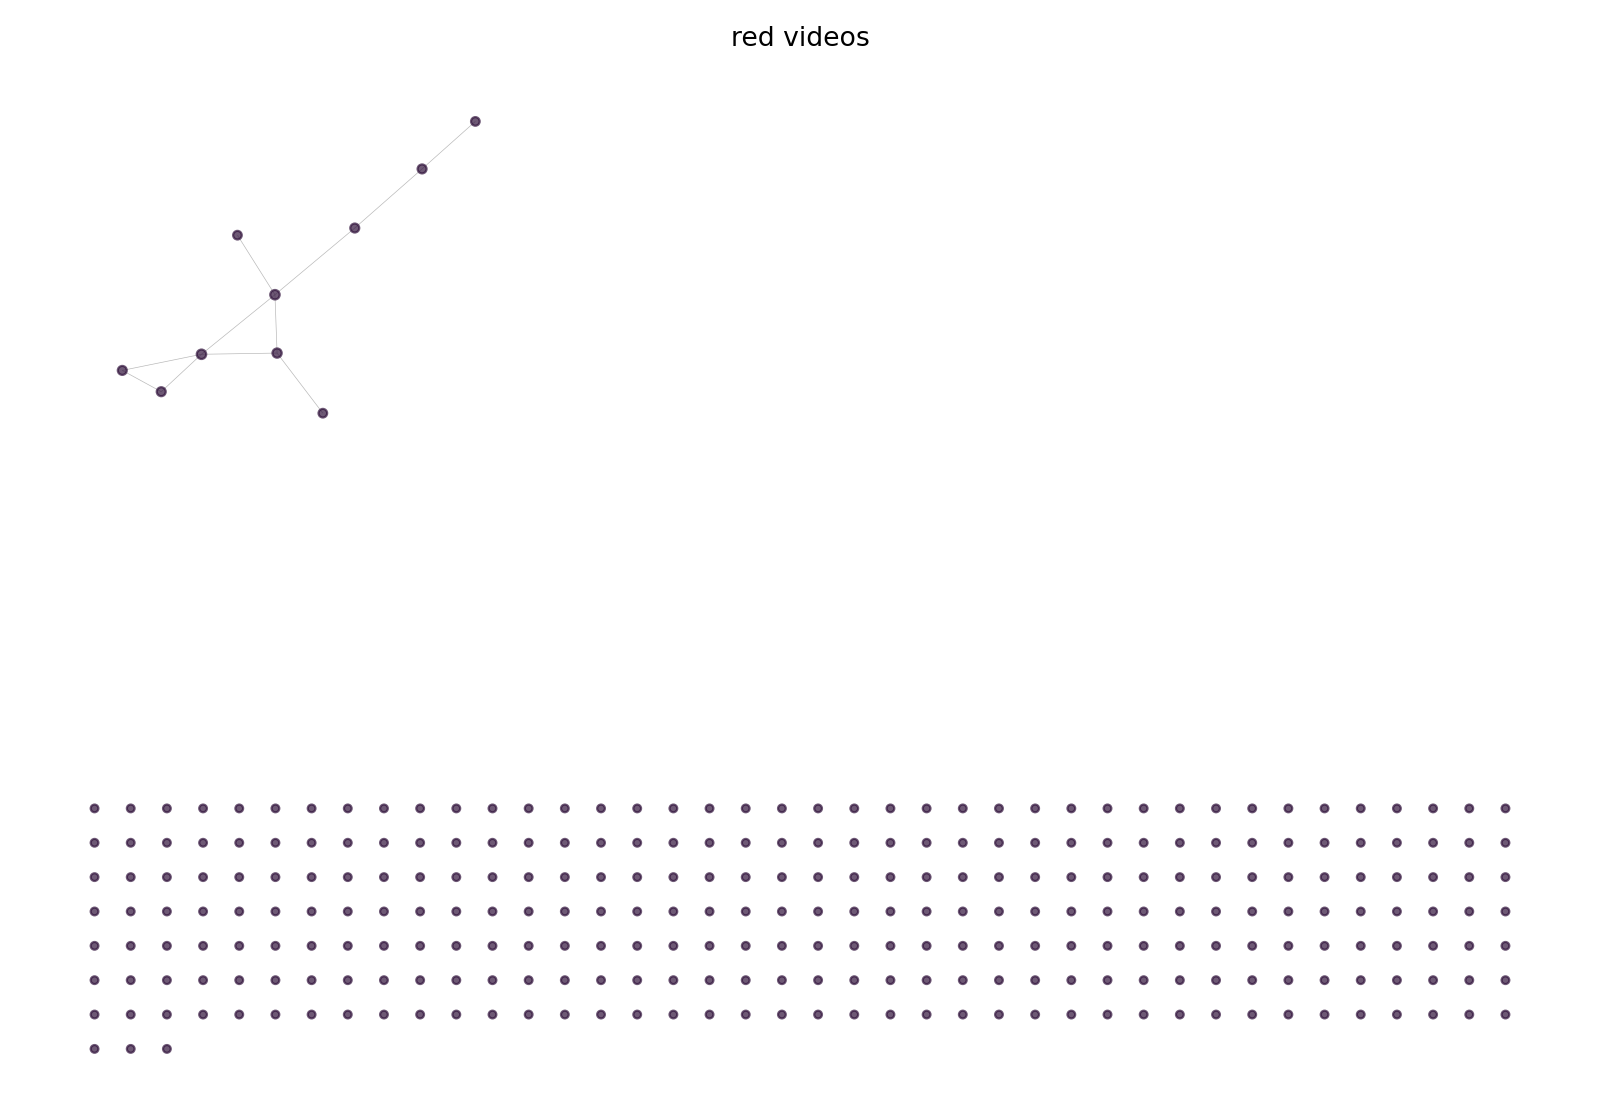

In [5]:
figura("red_videos")

La proyección de autores tiene 10732 aristas frente a 11 en videos. Cada video genera un grupo de autores completamente conectado, aunque estos no conversen. Esta expansión explica gran parte de la densidad y de los triángulos de la primera proyección.

## 6. Topología y fragmentación

La densidad general divide las aristas entre todos los pares posibles. En la bipartita también se informa la densidad respecto a pares autor-video permitidos. La cohesión se define como la fracción de pares de nodos que pueden alcanzarse por algún camino. La transitividad es la proporción de ternas conectadas que cierran un triángulo; el clustering medio promedia el cierre local incluyendo los ceros. Las dos últimas medidas son estructuralmente cero en la bipartita, porque no admite triángulos; no significan ausencia total de cohesión.

In [6]:
tabla("topologia", 20)

,red,nodos,aristas,densidad,grado_medio,componentes,componente_mayor,aislados,hojas,cohesion_pares,transitividad,clustering_medio,densidad_bipartita
0,bipartita,625,343,0.0018,1.0976,284,286,274,327,0.2117,0.0000,0.0000,0.0035
1,autores,332,10732,0.1953,64.6506,10,276,4,2,0.6991,0.9840,0.9720,NaN
2,videos,293,11,0.0003,0.0751,284,10,283,3,0.0011,0.3158,0.0097,NaN


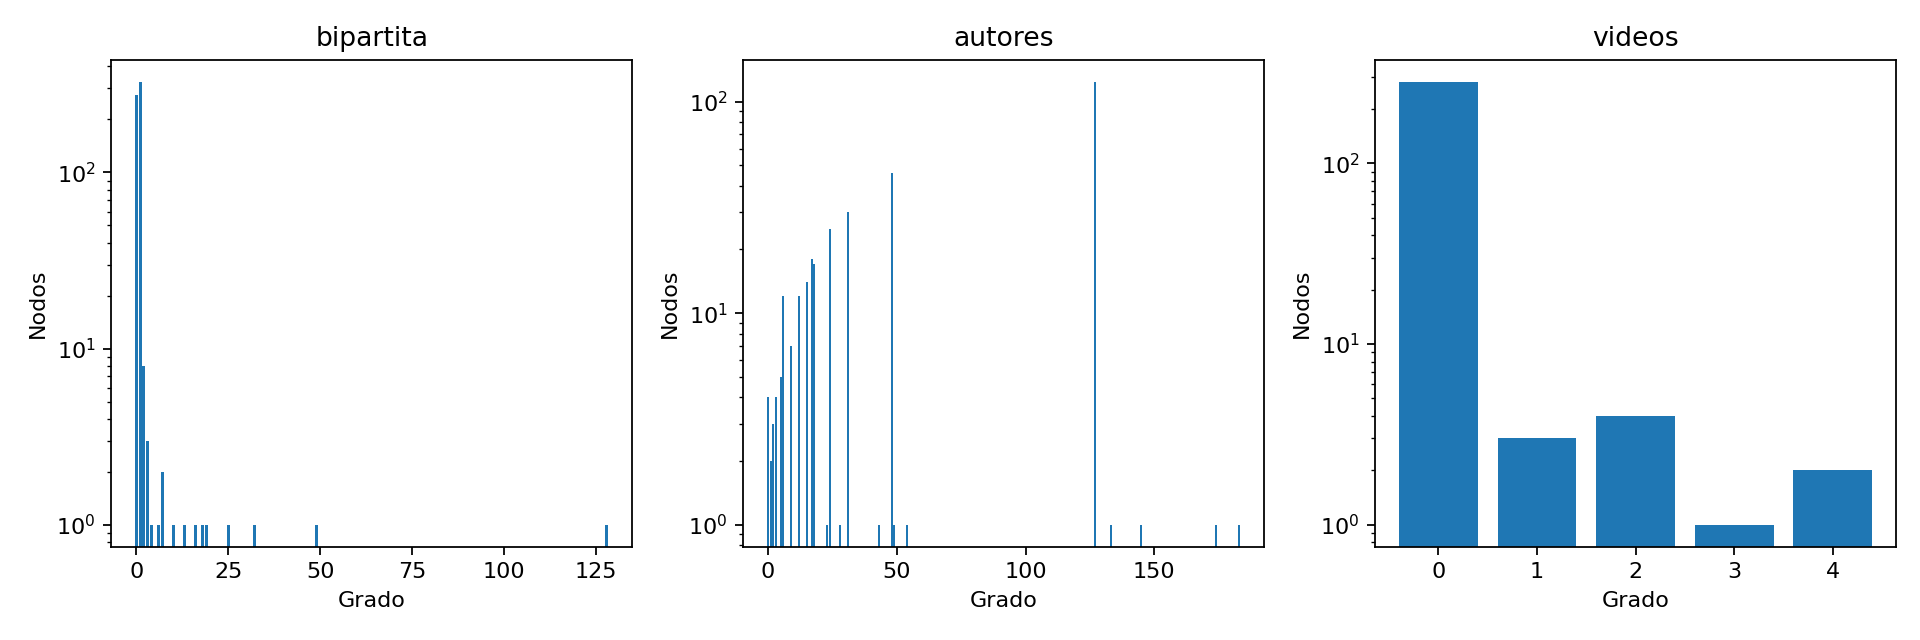

In [7]:
figura("distribucion_grados")

La bipartita contiene 625 nodos, 343 aristas y 284 componentes, con 286 nodos en la mayor. Sus 327 hojas muestran participación poco diversa. Hay 274 videos sin comentarios recolectados. La proyección de videos tiene 283 aislados: 274 sin cobertura y 9 con comentarios cuyos autores no aparecen en otros videos. Los 4 autores aislados en su proyección sí comentaron, pero no coinciden con otro autor en esos contenidos. La componente mayor de autores contiene 276 de 332 nodos; aun así, la transitividad de 0.984 refleja especialmente los grupos completos creados por la proyección. Los grados altos de autores pueden deberse a comentar en un video concurrido y no a recurrencia.

In [8]:
tabla("periferia_videos", 12)

,nodo_id,etiqueta,grado,estado
0,video:-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias para el fin de semana e...,0,aislado observado
1,video:-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO EL FIN DE UNA ETAPA...,0,aislado observado
2,video:-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado por Guatemala... 🔔,0,aislado observado
3,video:-O4Pa7qS9WQ,"Viaje completo Ciudad de Guatemala al IRTRA de Retalhuleu, menos t...",0,aislado observado
4,video:06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados d...,1,hoja
5,video:0LTLUY7LBlA,Qué debes saber ANTES de viajar a GUATEMALA | Dónde cambiar DINERO...,0,aislado observado
6,video:0a4_g1R1-aA,Acciones relevantes en el #Resumen24Horas,0,aislado observado
7,video:0b2vfzXdCqs,Cadena Nacional del presidente Bernardo Arévalo,0,aislado observado
8,video:0eiVPMexNOo,CONRED se pronuncia tras sismos en el territorio nacional,0,aislado observado
9,video:0iQD8zHxZIg,SE FILTRO un AUDIO de PANDILLEROS en Guatemala | DISPUTA POLITICA ...,0,aislado observado


In [9]:
tabla("periferia_autores", 12)

,nodo_id,etiqueta,grado,estado
0,autor:UC6xI_MOaxajIWpoP8BH6E_Q,@jahirdiaz5862,0,aislado observado
1,autor:UCJxJC56BSAX-ArD0NAb9qnQ,@alfonsowilian9157,1,hoja
2,autor:UCPLW0HE3siElqCgXfgWxMqg,@elizabethmonterroso7719,0,aislado observado
3,autor:UCQM2tCKRRytVDRxNUfCDqQQ,@elioelias7267,0,aislado observado
4,autor:UC_NRVt2UP88ZNTwzrZ66JSg,@aditalissethevasquezrojas8039,0,aislado observado
5,autor:UCyor0Mmm0ivLX2jIdyGp84Q,@MiguelJordan-n3g,1,hoja


## 7. Comunidades

Se elige la proyección de autores para agrupar patrones de participación compartida. Louvain optimiza modularidad mediante movimientos locales y agrupación de comunidades. Se usa el peso como cantidad de videos compartidos, resolución 1 y semilla 42. El método busca más conexiones internas que las esperadas bajo un modelo que conserva fuerzas; no garantiza el óptimo global ni grupos sociales reales. La proyección favorece los videos con muchos comentaristas. Las comunidades pequeñas pueden fusionarse por el límite de resolución. Los autores aislados se conservan como comunidades unitarias.

Se detectaron 14 comunidades y modularidad 0.3949. La tabla de semillas comprueba cuánto cambia este indicador con diferentes inicializaciones; una modularidad parecida no garantiza miembros idénticos.

In [10]:
tabla("calidad_comunidades", 20)

,semilla,comunidades,modularidad
0,42,14,0.3949
1,7,14,0.3949
2,21,14,0.3949


In [11]:
tabla("comunidades_resumen", 40)

,comunidad,autores,videos,canales,comentarios,palabras,positivo,negativo,neutral
0,1,126,3,3,161,"pueblo, dinero, diputados, trabajo, diputado, sueldo, tienen, todos",23,16,122
1,2,61,3,2,83,"presidente, guatemala, país, años, arevalo, bernardo, salvador, pu...",20,9,54
2,3,55,4,2,60,"usac, corruptos, universidad, estudiantes, información, excelente,...",10,6,44
3,4,28,3,1,33,"excelente, empresas, solo, internet, ley, está, país, competencia",13,3,17
4,5,25,1,1,25,"guatemala, ciudad, saludos, todos, viva, proyectos, tiempo, dios",5,0,20
5,6,18,1,1,25,"you, usa, pais, otros, país, if, to, ver",4,2,19
6,7,6,1,1,6,"asquerosos, gasolina, subira, guerra, países, guatemala, galón, país",1,0,5
7,8,4,1,1,4,"iniciativa, juego, excelente, ve, deporte, dinamico, entretenido, ...",2,0,2
8,9,3,1,1,3,"guatemala, solo, cambia, dictadura, años, vi, semilla, bernardo",0,1,2
9,10,2,1,1,2,"persona, encargada, ecosistema, ayude, problema, recuerdos, dejand...",0,1,1


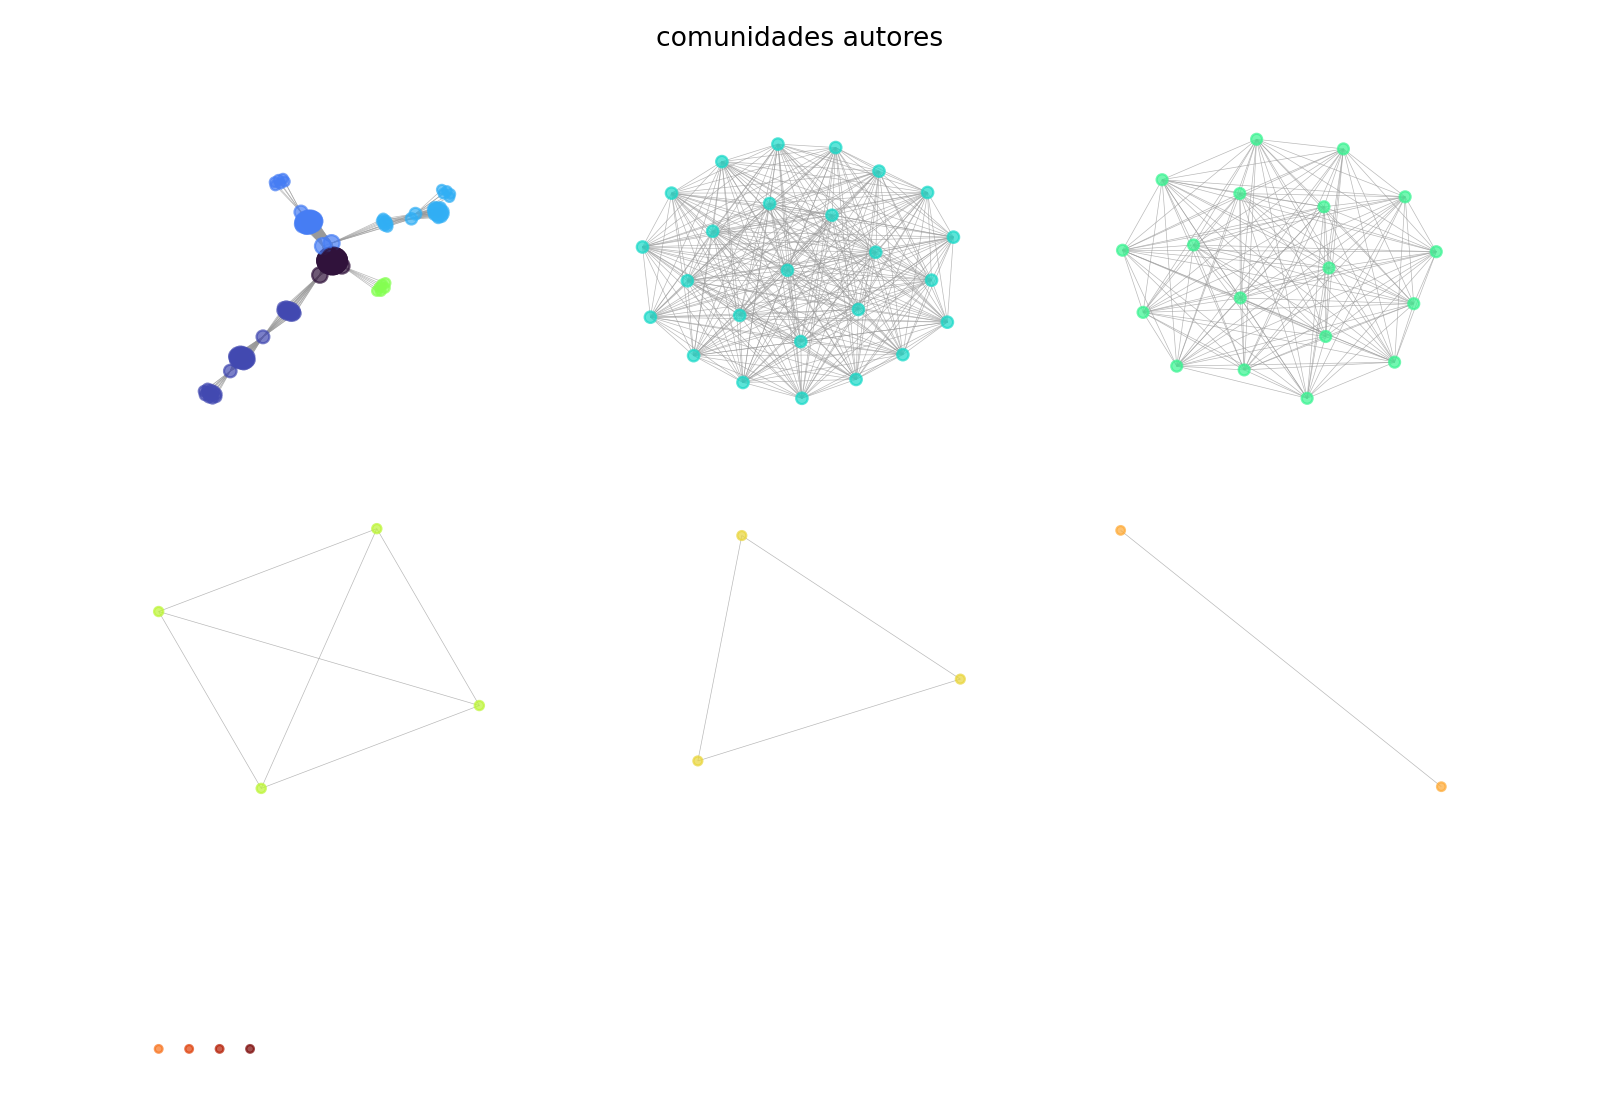

In [12]:
figura("comunidades_autores")

Cada color representa una comunidad en la figura y todos los nodos están incluidos. Los identificadores exactos se entregan en comunidades_autores.csv. Los colores ayudan a ubicar grupos; la tabla permite comparar incluso las comunidades unitarias. Los comentarios se asignan por la comunidad de su autor; un video puede aparecer en varias comunidades.

### Comunidad 1

Reúne 126 autores, 3 videos de 3 canales y 161 comentarios (1.28 por autor). Los contenidos son Qué rico come tu diputado; Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt; Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rutas principales. Los canales son Quorum; Gobierno de la República de Guatemala; PrensaLibreOficial. Los autores con más comentarios son @ManuelEdran: 5; @ErvinLeonardoCarreraLatín: 4; @HaroldoCastillo-rh9iw: 3. Las palabras más frecuentes son pueblo, dinero, diputados, trabajo, diputado, sueldo, tienen, todos. El léxico asigna 23 positivos, 16 negativos y 122 neutrales. Estas palabras describen el contenido y no prueban que los miembros compartan una postura.

### Comunidad 2

Reúne 61 autores, 3 videos de 2 canales y 83 comentarios (1.36 por autor). Los contenidos son Inician los trabajos de recuperación del Puente Belice II.; Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt; Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto. Los canales son Gobierno de la República de Guatemala; Noti7. Los autores con más comentarios son @Murmullodelbarrio: 6; @albertoshernandez5251: 5; @ErmePérez-q4s: 3. Las palabras más frecuentes son presidente, guatemala, país, años, arevalo, bernardo, salvador, puente. El léxico asigna 20 positivos, 9 negativos y 54 neutrales. Estas palabras describen el contenido y no prueban que los miembros compartan una postura.

### Comunidad 3

Reúne 55 autores, 4 videos de 2 canales y 60 comentarios (1.09 por autor). Los contenidos son La cooptación de Walter Mazariegos en la USAC; Capturan a ladrón que había quedado grabado mientras robaba en una parroquia de Retalhuleu; Qué rico come tu diputado; Internet: escoger el menos malo. Los canales son Quorum; TN23 Guatemala. Los autores con más comentarios son @Jel.Awesh.M: 3; @inge_vergueta: 3; @MarcosCarillo-b1r: 2. Las palabras más frecuentes son usac, corruptos, universidad, estudiantes, información, excelente, pueblo, pacto. El léxico asigna 10 positivos, 6 negativos y 44 neutrales. Estas palabras describen el contenido y no prueban que los miembros compartan una postura.

Las tres comunidades principales reúnen conversaciones sobre diputados y recursos públicos, gobierno e infraestructura, y la USAC. Predomina la etiqueta neutral en las tres, pero la cobertura limitada del léxico impide afirmar que predomine una actitud neutral. El grupo gubernamental presenta más positivos que negativos reconocidos; las críticas políticas pueden quedar sin identificar por vocabulario no incluido, como plurales o expresiones locales.

## 8. Nodos centrales y participantes puente

Se calculan grado, fuerza, intermediación y cercanía en la red bipartita. El grado de un autor cuenta videos distintos y su fuerza cuenta comentarios; para un video cuentan autores distintos y comentarios, respectivamente. La intermediación normalizada mide la fracción de caminos mínimos que atraviesan el nodo. Se usan caminos sin pesos porque frecuencia no es distancia. La cercanía incorpora la corrección de Wasserman-Faust para componentes desconectadas, de modo que se reduce cuando pocos nodos son alcanzables. No se comparan autores y videos como si cumplieran la misma función.

In [13]:
tabla("centralidad", 15)

,nodo_id,tipo,etiqueta,grado,fuerza,intermediacion,cercania,articulacion,aumento_componentes,canales
0,video:n8iP75gIpmw,video,Qué rico come tu diputado,128,161,0.1777,0.1708,True,126,NaN
1,video:PjmxCj-a9Hg,video,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,19,25,0.0767,0.1210,True,18,NaN
2,autor:UCHTGCgY2l-DQJIvlA_cpa_Q,autor,@virgiliogarcia3039,2,3,0.0728,0.1418,True,1,2.0
3,video:j43HgwYFKfk,video,La cooptación de Walter Mazariegos en la USAC,49,50,0.0715,0.1242,True,47,NaN
4,autor:UCpsKOkt5iWTbenzeuq7dsmQ,autor,@inge_vergueta,3,3,0.0685,0.1489,True,1,1.0
5,video:6W4u8sGEnGM,video,Inician los trabajos de recuperación del Puente Belice II.,32,45,0.0590,0.0888,True,31,NaN
6,autor:UCzZ6dDCEsLMXbc5pCFXIprw,autor,@josegil3813,2,2,0.0556,0.1025,True,1,1.0
7,video:ndAZjHqzzT8,video,Internet: escoger el menos malo,10,12,0.0403,0.1186,True,8,NaN
8,autor:UCylqlpsh8ENNM1LqgQ1KbxA,autor,@Jel.Awesh.M,2,3,0.0280,0.1391,False,0,1.0
9,video:yLZS3JiEBg8,video,Arroz con pollo a la MONOPOLIO,16,16,0.0200,0.0817,True,14,NaN


In [14]:
tabla("articulaciones", 30)

,nodo_id,tipo,etiqueta,grado,fuerza,intermediacion,cercania,articulacion,aumento_componentes,canales
0,video:n8iP75gIpmw,video,Qué rico come tu diputado,128,161,0.1777,0.1708,True,126,NaN
1,video:PjmxCj-a9Hg,video,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,19,25,0.0767,0.1210,True,18,NaN
2,autor:UCHTGCgY2l-DQJIvlA_cpa_Q,autor,@virgiliogarcia3039,2,3,0.0728,0.1418,True,1,2.0
3,video:j43HgwYFKfk,video,La cooptación de Walter Mazariegos en la USAC,49,50,0.0715,0.1242,True,47,NaN
4,autor:UCpsKOkt5iWTbenzeuq7dsmQ,autor,@inge_vergueta,3,3,0.0685,0.1489,True,1,1.0
5,video:6W4u8sGEnGM,video,Inician los trabajos de recuperación del Puente Belice II.,32,45,0.0590,0.0888,True,31,NaN
6,autor:UCzZ6dDCEsLMXbc5pCFXIprw,autor,@josegil3813,2,2,0.0556,0.1025,True,1,1.0
7,video:ndAZjHqzzT8,video,Internet: escoger el menos malo,10,12,0.0403,0.1186,True,8,NaN
8,video:yLZS3JiEBg8,video,Arroz con pollo a la MONOPOLIO,16,16,0.0200,0.0817,True,14,NaN
9,autor:UCvcu1kR8xMYy_I1Ty-2mV2Q,autor,@hashojea7348,3,4,0.0188,0.0971,True,1,1.0


Entre los nodos de tipo autor, @virgiliogarcia3039 tiene la mayor intermediación (0.0728), grado 2 y fuerza 3. Al eliminarlo, el número de componentes aumenta en 1. Su papel de puente proviene de conectar contenidos y debe distinguirse del volumen de comentarios.

Entre los nodos de tipo video, Qué rico come tu diputado tiene la mayor intermediación (0.1777), grado 128 y fuerza 161. Al eliminarlo, el número de componentes aumenta en 126. Su capacidad articuladora incluye desconectar autores que solo aparecen en ese video; no equivale necesariamente a conectar varios temas.

Hay 9 autores recurrentes en varios videos y 4 que cruzan canales. Se identifican 7 autores y 15 videos de articulación. La columna aumento_componentes verifica cada eliminación por separado, manteniendo los demás nodos. La recurrencia por sí sola no basta para ser punto de articulación.

## 9. Contenido y sentimiento

Se usa el léxico español definido en analisis_avance.py, con términos positivos como excelente, gracias y apoyo y negativos como corrupción, mentira y violencia. Es una herramienta de reglas propia, transparente y reproducible, adecuada al idioma pero de cobertura limitada y sin validación externa de precisión. Se aplica a texto_original, no al texto sin stopwords. Se normalizan mayúsculas y tildes, se suman ocurrencias positivas y se restan negativas. No, nunca, jamás y sin invierten el signo dentro de las tres palabras previas sin cruzar la puntuación reconocida. Un puntaje mayor que cero es positivo, menor que cero negativo y cero neutral. No se usa VADER en inglés.

La regla no resuelve ironía, citas, sujeto del sentimiento, todos los límites de negación, emojis ni variantes morfológicas. Neutral incluye ausencia de coincidencias y cancelación de signos. Hablar de corrupción o muerte puede describir una noticia sin expresar una valoración. Estos conteos son etiquetas del método y no una medición validada de opinión política.

In [15]:
tabla("sentimiento_global", 20)

,sentimiento,comentarios
0,neutral,289
1,positivo,79
2,negativo,38


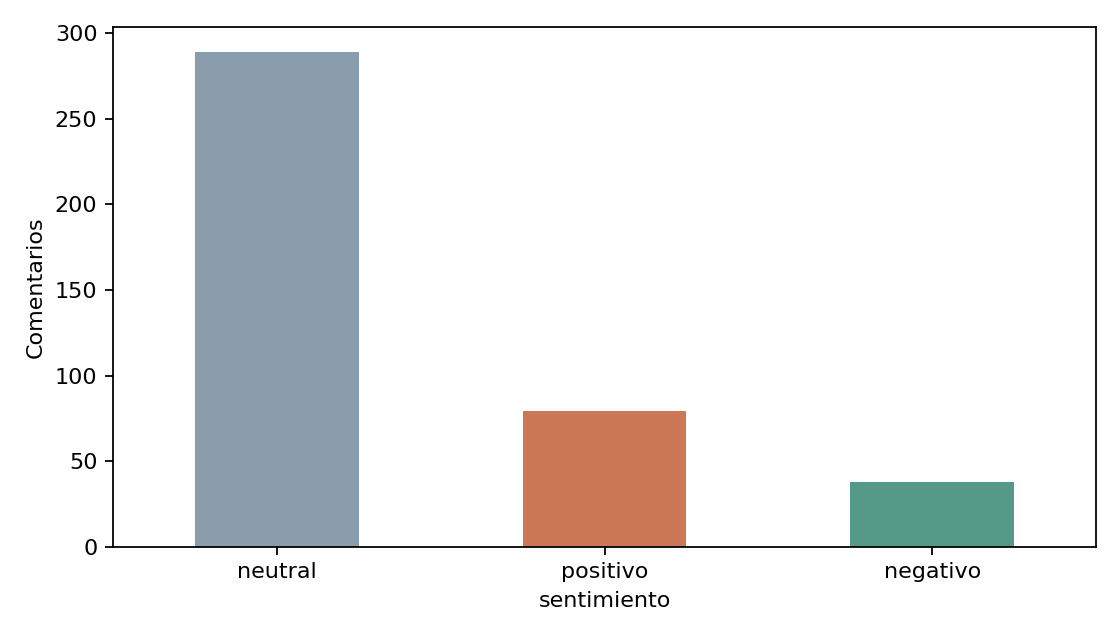

In [16]:
figura("sentimiento")

In [17]:
tabla("sentimiento_video_id", 30)

,video_id,positivo,negativo,neutral,n,porcentaje_positivo,porcentaje_negativo,porcentaje_neutral,comparacion_descriptiva
0,06mFNPU0aB8,2,0,12,14,14.2857,0.0000,85.7143,True
1,3Nfp9h5avBI,0,1,1,2,0.0000,50.0000,50.0000,False
2,6W4u8sGEnGM,13,7,25,45,28.8889,15.5556,55.5556,True
3,JkpVO1hx2f8,0,1,2,3,0.0000,33.3333,66.6667,False
4,OkXlHx0hx-8,4,2,19,25,16.0000,8.0000,76.0000,True
5,PjmxCj-a9Hg,5,2,18,25,20.0000,8.0000,72.0000,True
6,TT4qJ5FXHYE,2,0,2,4,50.0000,0.0000,50.0000,False
7,UhL9y3KUl8E,1,0,0,1,100.0000,0.0000,0.0000,False
8,WIUZtitfLRw,3,1,2,6,50.0000,16.6667,33.3333,False
9,X_FAIef8qlE,0,0,1,1,0.0000,0.0000,100.0000,False


In [18]:
tabla("sentimiento_channel_name", 30)

,channel_name,positivo,negativo,neutral,n,porcentaje_positivo,porcentaje_negativo,porcentaje_neutral,comparacion_descriptiva
0,Gobierno de la República de Guatemala,18,9,43,70,25.7143,12.8571,61.4286,True
1,Municipalidad de Guatemala,5,0,20,25,20.0000,0.0000,80.0000,True
2,Noti7,2,0,12,14,14.2857,0.0000,85.7143,True
3,Noticias Telemundo,4,2,19,25,16.0000,8.0000,76.0000,True
4,Noticiero Guatevisión 13 Hrs.,0,1,1,2,0.0000,50.0000,50.0000,False
5,PrensaLibreOficial,1,0,6,7,14.2857,0.0000,85.7143,False
6,Quorum,49,26,181,256,19.1406,10.1562,70.7031,True
7,TN23 Guatemala,0,0,7,7,0.0000,0.0000,100.0000,False


In [19]:
tabla("sentimiento_comunidad", 30)

,comunidad,positivo,negativo,neutral,n,porcentaje_positivo,porcentaje_negativo,porcentaje_neutral,comparacion_descriptiva
0,1,23,16,122,161,14.2857,9.9379,75.7764,True
1,2,20,9,54,83,24.0964,10.8434,65.0602,True
2,3,10,6,44,60,16.6667,10.0000,73.3333,True
3,4,13,3,17,33,39.3939,9.0909,51.5152,True
4,5,5,0,20,25,20.0000,0.0000,80.0000,True
5,6,4,2,19,25,16.0000,8.0000,76.0000,True
6,7,1,0,5,6,16.6667,0.0000,83.3333,False
7,8,2,0,2,4,50.0000,0.0000,50.0000,False
8,9,0,1,2,3,0.0000,33.3333,66.6667,False
9,10,0,1,1,2,0.0000,50.0000,50.0000,False


In [20]:
tabla("sentimiento_source_query", 30)

,source_query,positivo,negativo,neutral,n,porcentaje_positivo,porcentaje_negativo,porcentaje_neutral,comparacion_descriptiva
0,@GobiernodeGuatemala,5,2,18,25,20.0000,8.0000,72.0000,True
1,@quorumgt,8,4,13,25,32.0000,16.0000,52.0000,True
2,@quorumgt/videos,41,22,168,231,17.7489,9.5238,72.7273,True
3,Gobierno de la República de Guatemala,13,7,25,45,28.8889,15.5556,55.5556,True
4,Municipalidad de Guatemala,5,0,20,25,20.0000,0.0000,80.0000,True
5,guatemala noticias,7,3,45,55,12.7273,5.4545,81.8182,True


En el conjunto completo, 79 comentarios son positivos, 38 negativos y 289 neutrales según el léxico. Quorum reúne 256 comentarios, con 19.14 por ciento positivos y 10.16 por ciento negativos; el canal del Gobierno reúne 70, con 25.71 por ciento positivos y 12.86 por ciento negativos. La diferencia de porcentajes no demuestra una mejor recepción del Gobierno: cambian los videos, las personas y la cobertura. Los dos comentarios de Noticiero Guatevisión no permiten una comparación estable aunque uno tenga etiqueta negativa.

Se muestran los tamaños y porcentajes por grupo. Solo se comparan descriptivamente grupos con al menos 10 comentarios; ese umbral práctico no garantiza representatividad. source_query se usa como tema de recolección, no como clasificación temática validada. No se realizan pruebas de diferencias poblacionales, ya que los comentarios no forman una muestra aleatoria y los autores pueden repetir participación.

## 10. Interpretación y conclusiones

La participación recolectada se concentra en pocos contenidos. La red de autores parece densa porque cada video conecta a sus comentaristas entre sí, mientras la proyección de videos muestra pocos cruces. Los autores puente son escasos y sostienen conexiones que pueden desaparecer al retirar un solo participante. Las comunidades reflejan principalmente los contenidos comentados, con asuntos de gasto público, gobierno e infraestructura y universidad entre los grupos mayores. El sentimiento aporta una descripción léxica limitada, que no permite atribuir posturas a todas las audiencias.

La cobertura alcanza solo 19 de 293 videos y no equivale al total de comentarios publicados. La selección por consultas y canales limita qué temas aparecen. Las fechas relativas no permiten una cronología exacta. Las visualizaciones, respuestas y me gusta son conteos del momento de recolección, sujetos a cambio. No hay relaciones explícitas entre autores ni identificación de quienes respondieron. La concentración en pocos videos puede mezclar actividad y diferencias de recolección. Un video sin comentarios en estos archivos no necesariamente carece de ellos en YouTube.

Los conteos de nodos y palabras son descripciones. Las correlaciones entre visualizaciones y comentarios y los cruces de audiencia son asociaciones observadas. No se establece causalidad ni se hace inferencia hacia todos los usuarios de YouTube o la población de Guatemala. Redes, contenido y sentimiento deben leerse juntos con estas restricciones.

## Referencias

NetworkX. Louvain communities. https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html

NetworkX. Betweenness centrality. https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.betweenness_centrality.html

NetworkX. Closeness centrality. https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.closeness_centrality.html

Repositorio y espacio colaborativo de código: https://github.com/Ninaswiftie09/Data_Science/tree/Laboratorio6